(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

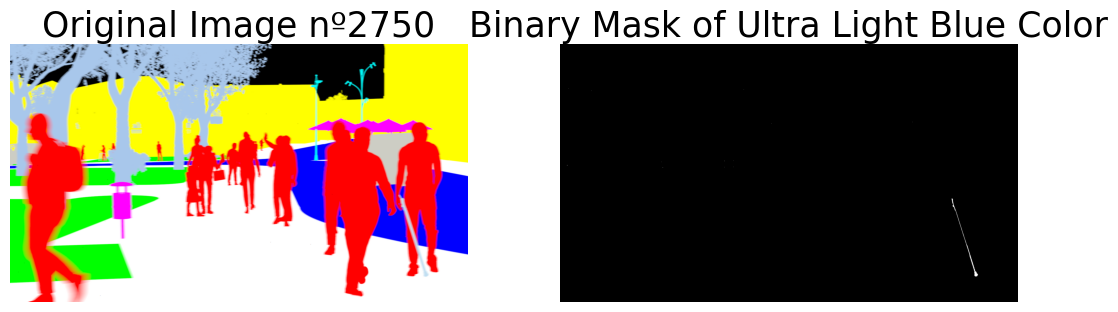

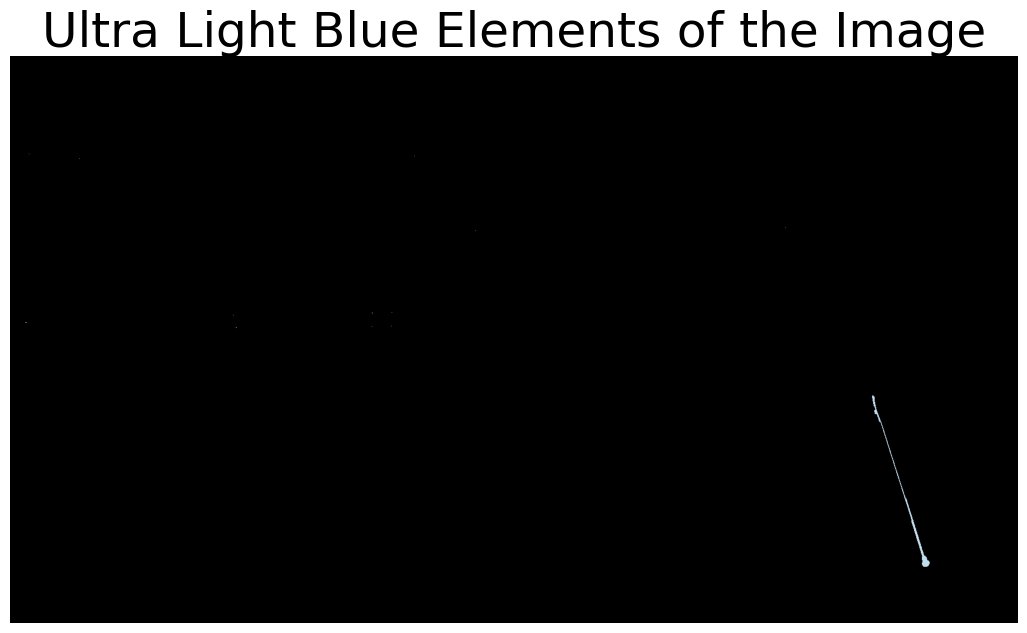

In [156]:
import sys
import os

# Adicione o caminho da pasta raiz do projeto ao sys.path
sys.path.append(os.path.abspath('/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'))
# sys.path.append(os.path.abspath(r'C:\Users\Renato\Documents\GitHub\pucpr_pibic_semantic_segmentation'))
# sys.path.append(os.path.abspath('/home/santiago/Doctorado/Entrenamientos/pucpr_pibic_semantic_segmentation-main/'))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

### Refatoração: Processo de Separação para Ultra Light Blue

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.waitKey(0)
# cv.destroyAllWindows()

# Segmentation by Limits
# Define limits for Ultra Light Blue Color >> HSV (H:90, S:40, V:230) to (H:105, S:60, V:245)
lower_bound = np.array([90, 40, 230])  # Hue, Saturation, Value
upper_bound = np.array([105, 60, 245]) # Hue, Saturation, Value

# Create binary mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask of Ultra Light Blue Color",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Ultra Light Blue Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [55]:
# Run the previous code block to inspect
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

In [5]:
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

'\nExiste distorção nos valores para segmentação por cores.\nFoi decidido aplicar a redução da imagem APÓS a segmentação para evitar a perda de informação.\n'

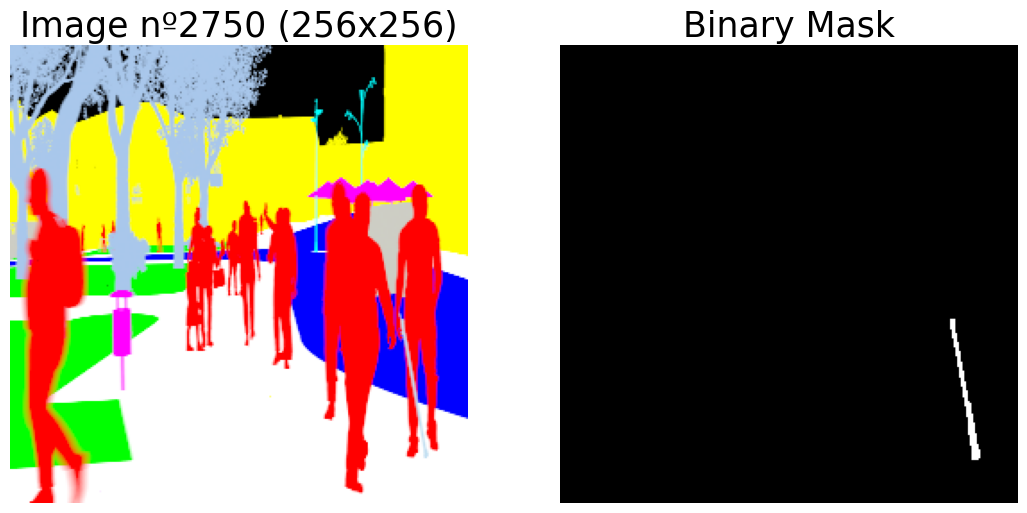

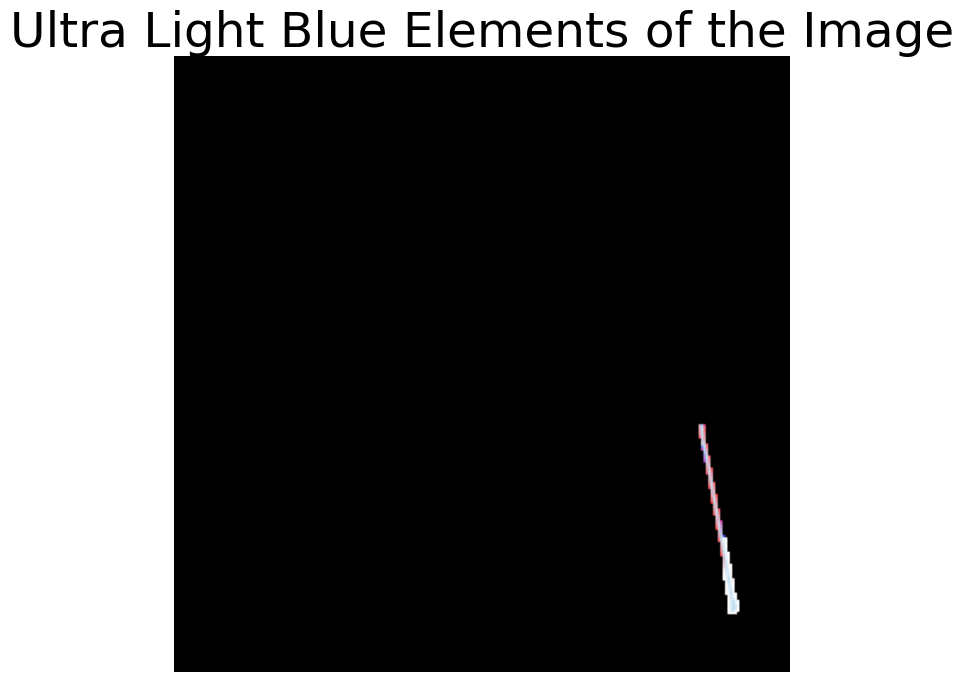

In [ ]:
# Quality Test for Binary Mask (2750.npy) with img resize to 256x256

import sys
import os

sys.path.append(os.path.abspath('/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'))
# sys.path.append(os.path.abspath(r'C:\Users\Renato\Documents\GitHub\pucpr_pibic_semantic_segmentation'))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

### Setup ###
load_dotenv()

base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

### Refatoração: Processo de Separação para Ultra Light Blue

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)

# Redimensionar a imagem para 256x256
# bgr_img = cv.resize(bgr_img, (256, 256), interpolation=cv.INTER_AREA)
bgr_img = cv.resize(bgr_img, (256, 256), interpolation=cv.INTER_CUBIC) # more complex and slow, but have a better quality

# Converter para HSV
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# # Segmentation by Limits (1920x1080)
# # Define limits for Ultra Light Blue Color >> HSV (H:90, S:40, V:230) to (H:105, S:60, V:245)
# lower_bound = np.array([90, 40, 230])  # Hue, Saturation, Value
# upper_bound = np.array([105, 60, 245]) # Hue, Saturation, Value

# # Try new Limits (256x256) (Still not good)
# # Define limits for Ultra Light Blue Color >> HSV (H:90, S:40, V:230) to (H:104, S:60, V:245)
lower_bound = np.array([100, 15, 230])  # Hue ok, Saturation ok, Value ok
upper_bound = np.array([104, 60, 255])  # Hue ?, Saturation ok, Value ok

# Create binary mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)


# https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html
# # Morphologic Operation (Binary Closing)
kernel = np.ones((3,3), np.uint8)
dilated_mask = cv.dilate(mask, kernel, iterations=3)
erosion_mask = cv.erode(dilated_mask, kernel, iterations=2)


# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Image nº{img_number} (256x256)",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
# plt.imshow(mask, cmap='gray')
# plt.imshow(dilated_mask, cmap='gray')
plt.imshow(erosion_mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
# result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)
# result = cv.bitwise_and(bgr_img, bgr_img, mask=dilated_mask)
result = cv.bitwise_and(bgr_img, bgr_img, mask=erosion_mask)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Ultra Light Blue Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

"""
Existe distorção nos valores para segmentação por cores.
Foi decidido aplicar a redução da imagem APÓS a segmentação para evitar a perda de informação.
"""

In [129]:
# Run the previous code block to inspect
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

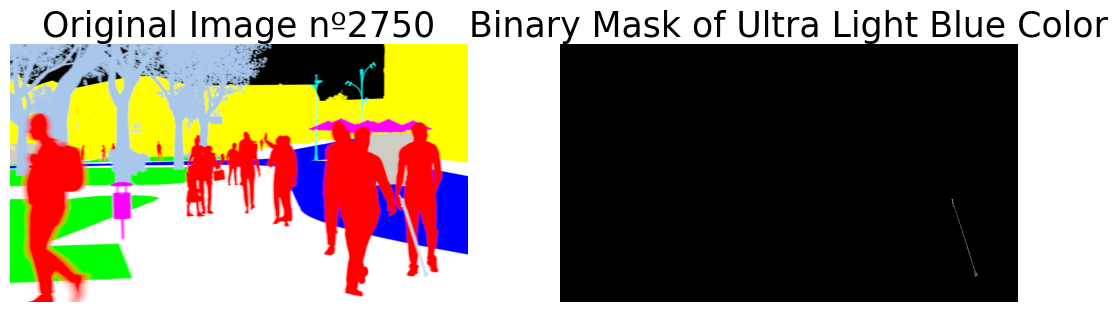

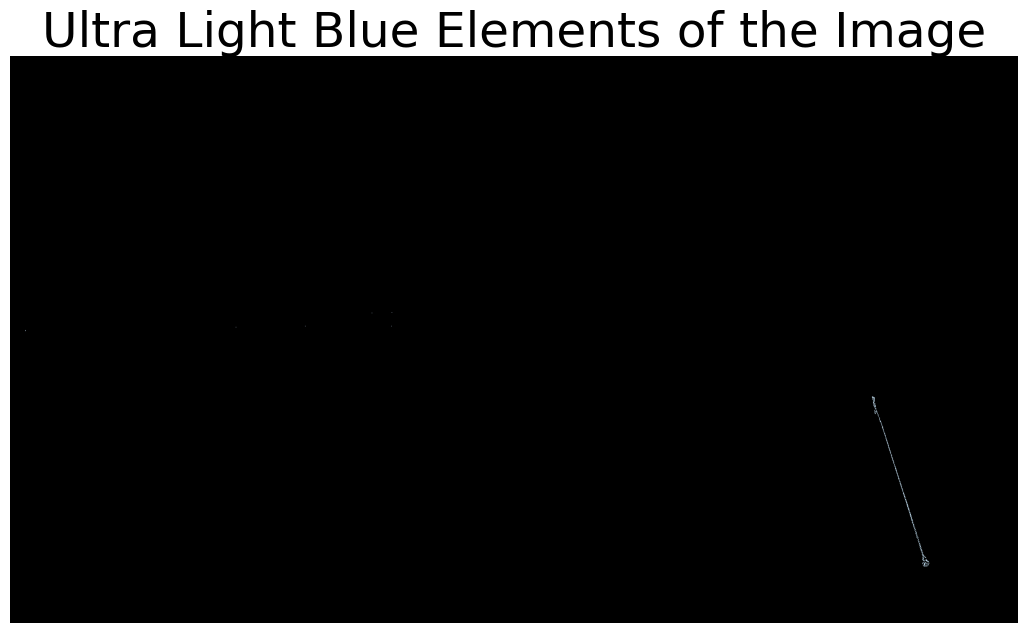

In [43]:
# Using Segmentation by Euclidean Distance
import sys
import os

# Adicione o caminho da pasta raiz do projeto ao sys.path
sys.path.append(os.path.abspath('/home/renato/Work/pucpr_pibic_semantic_segmentation/'))
# sys.path.append(os.path.abspath('/home/santiago/Doctorado/Entrenamientos/pucpr_pibic_semantic_segmentation-main/'))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
# import os


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

### Refatoração: Processo de Separação para LIGHT ORANGE 20

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.waitKey(0)
# cv.destroyAllWindows()

# # Segmentation by Limits
# # Define limits for Light Orange Color >> HSV (H:90, S:40, V:230) to (H:105, S:51, V:245)
# lower_bound = np.array([90, 40, 230])  # Hue, Saturation, Value
# upper_bound = np.array([105, 51, 245]) # Hue, Saturation, Value

# # Create binary mask
# mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# Segmentation by Euclidean Distance
# Define target color in HSV (e.g., ultra light blue)
target_color = np.array([102, 47, 238])  # Hue, Saturation, Value

# Calculate Euclidean distance from the target color
distance = np.sqrt(np.sum((hsv_img - target_color) ** 2, axis=-1))

# Apply threshold to create the mask
threshold = 5  # Define acceptable distance
mask = (distance < threshold).astype(np.uint8) * 255


# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask of Ultra Light Blue Color",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Ultra Light Blue Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [37]:
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

In [44]:
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

TEST: 512x512 with new method and new limits

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

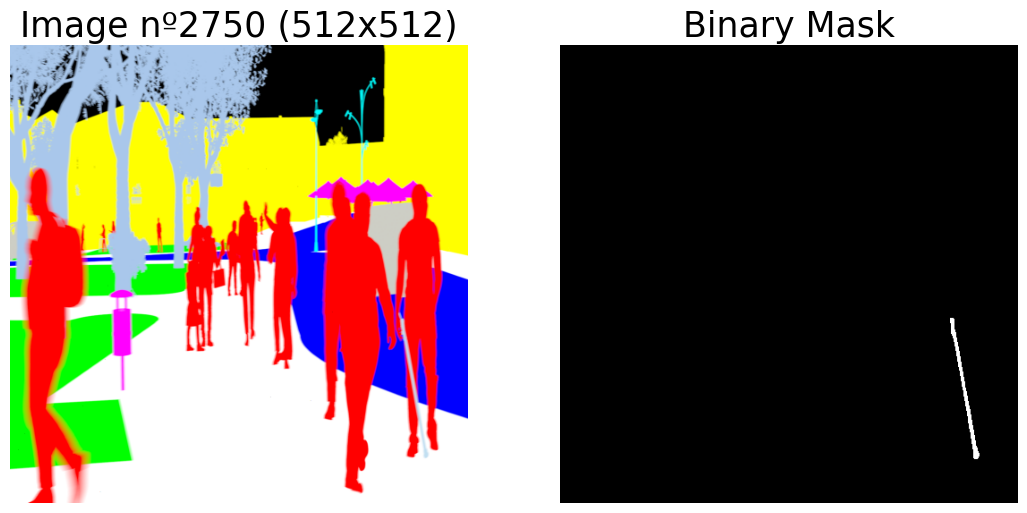

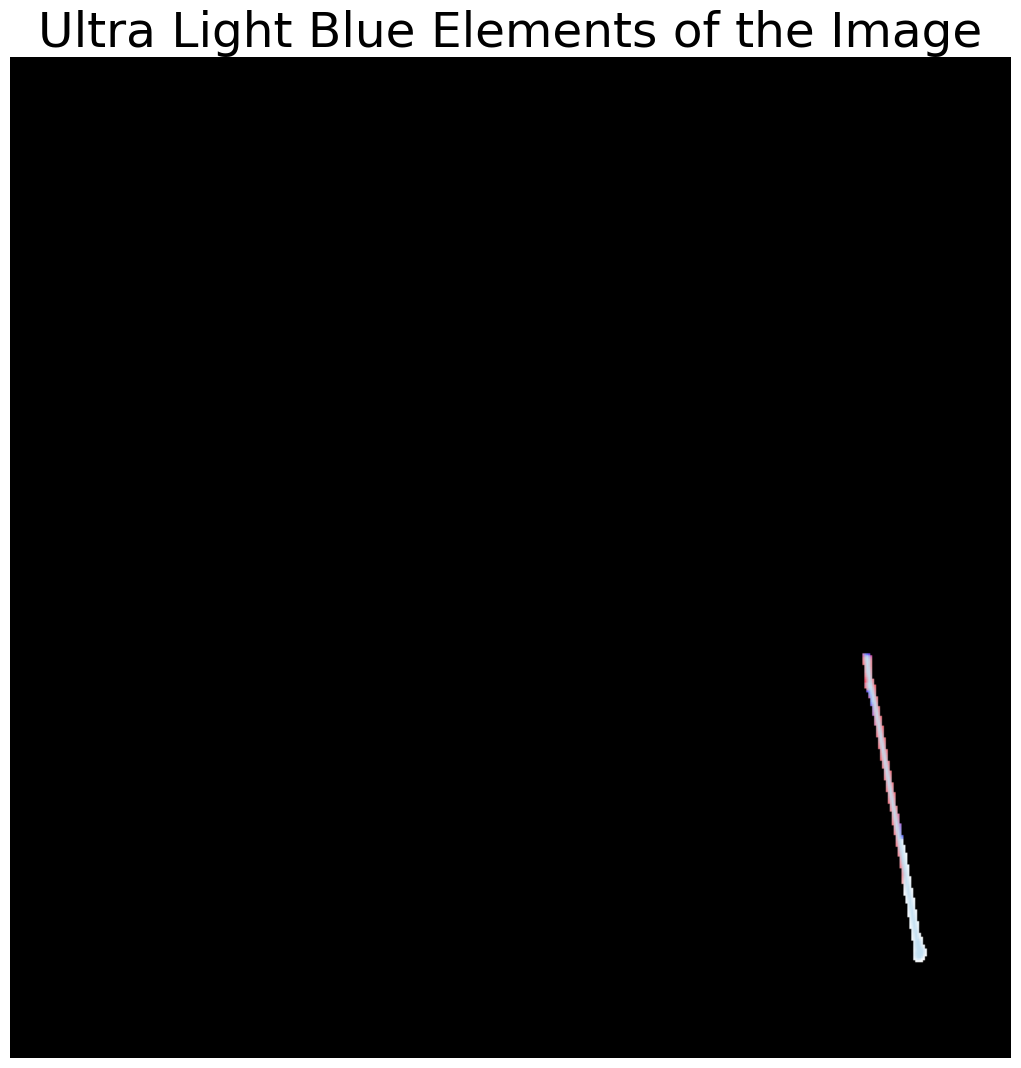

In [4]:
# Quality Test for Binary Mask (3808.npy) with img resize to 512x512
# Element close with better definition

import sys
import os

# Adicione o caminho da pasta raiz do projeto ao sys.path
sys.path.append(os.path.abspath(r'/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
# import os


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

### Refatoração: Processo de Separação para LIGHT ORANGE ###

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)

# Resize image to 512x512
# bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA) #Recommended for shrink image

# Convert to HSV for segmentation
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.waitKey(0)
# cv.destroyAllWindows()

# Old limits for 1920x1080
# Define limits for Ultra Light Blue Color >> HSV (H:90, S:40, V:230) to (H:105, S:60, V:245)
lower_bound = np.array([90, 40, 230])  # Hue, Saturation, Value
upper_bound = np.array([105, 60, 245]) # Hue, Saturation, Value

# New limits for 512x512
# Define limits for Ultra Light Blue Color >> HSV (H:90, S:40, V:230) to (H:105, S:60, V:245)
# lower_bound = np.array([100, 15, 230])  # Hue ok, Saturation ok, Value ?
# upper_bound = np.array([120, 60, 254])  # Hue ok, Saturation ok, Value ok

# Create binary mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)
mask = 255 * (mask > 0).astype(np.uint8)

# Resize image to 512x512 AFTER
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA) #Recommended for shrink image
mask = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA) #Recommended for shrink image

# https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html
# Attempt 1 (not good)
# # Morphologic Operation (Binary Closing)
# kernel = np.ones((3,3), np.uint8)
# dilated_mask = cv.dilate(mask, kernel, iterations=2)
# # erosion_mask = cv.erode(dilated_mask, kernel, iterations=1)
# mask = cv.erode(dilated_mask, kernel, iterations=1)


# Attempt 2 (not good enough)
# kernel = np.ones((3,3), np.uint8)
# closing = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)
# opening = cv.morphologyEx(closing, cv.MORPH_OPEN, kernel)
# opening = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)


# Attempt 3: Use contours as filter + Binary Closing (seems the right path)
# # Solution for filter the noise
contours, hierarchy = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 3 # manual fine tuning (o. cane, o. crutch)

# Filter
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        cv.drawContours(filtered_mask, [contour], -1, (255), -1)

# Reassign mask with the filtered mask
mask = filtered_mask

kernel = np.ones((3,3), np.uint8)
dilated_mask = cv.dilate(mask, kernel, iterations=2)
mask = cv.erode(dilated_mask, kernel, iterations=1)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Image nº{img_number} (512x512)",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
# plt.imshow(erosion_mask, cmap='gray')
# plt.imshow(dilated_mask, cmap='gray')
# plt.imshow(opening, cmap='gray')
# plt.imshow(closing, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)
# result = cv.bitwise_and(bgr_img, bgr_img, mask=erosion_mask)
# result = cv.bitwise_and(bgr_img, bgr_img, mask=dilated_mask)
# result = cv.bitwise_and(bgr_img, bgr_img, mask=opening)
# result = cv.bitwise_and(bgr_img, bgr_img, mask=closing)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Ultra Light Blue Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [99]:
# Run the previous code block to inspect
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()